# Exact matrix inversion in integer arithmetic

Implementation in [`exact_elimination.py`](exact_elimination.py). No floating
point is involved at any point, so the inverse is exact rather than nearly right.

To clear an entry against a pivot, scale both rows by integers chosen so the
subtraction cancels: the pair is `(pivot/g, entry/g)` with `g` their gcd. Both
multipliers are integers, so the matrix stays integral throughout.

Three earlier defects, all of which defeated the exactness this exists to show:
there was no pivoting, so a zero on the diagonal annihilated a row instead of
failing; the arrays were `int64`, so exactness silently ended around n=8; and it
stopped one step short of ever dividing through to produce an inverse.

In [1]:
import numpy as np
from fractions import Fraction
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7.5, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})
from exact_elimination import inverse, diagonalise, elimination_multipliers, to_float

## The result is exact, not approximate

In [2]:
A = np.array([[4, 7, 5], [2, 6, 7], [1, 2, 3]])
inverse_of_A = inverse(A)
print("A inverse, as exact fractions:")
for row in inverse_of_A:
    print("   ", "  ".join(str(value).rjust(7) for value in row))
product = np.array(A, dtype=object) @ inverse_of_A
print("\nA @ A_inverse, exactly:")
print(product)
print("\nevery entry is exactly 0 or 1:",
      all(product[i, j] == (1 if i == j else 0) for i in range(3) for j in range(3)))

A inverse, as exact fractions:
       4/13   -11/13    19/13
       1/13     7/13   -18/13
      -2/13    -1/13    10/13

A @ A_inverse, exactly:
[[Fraction(1, 1) Fraction(0, 1) Fraction(0, 1)]
 [Fraction(0, 1) Fraction(1, 1) Fraction(0, 1)]
 [Fraction(0, 1) Fraction(0, 1) Fraction(1, 1)]]

every entry is exactly 0 or 1: True


## A zero on the diagonal

This matrix is invertible. Without pivoting it used to come back as an all-zero
array, with a divide-by-zero warning and no exception.

In [3]:
tricky = np.array([[0, 1, 1], [1, 0, 1], [1, 1, 0]])
print(inverse(tricky))
print("\nA @ A_inverse == I:",
      np.array_equal(np.array(tricky, dtype=object) @ inverse(tricky), np.eye(3, dtype=object)))

[[Fraction(-1, 2) Fraction(1, 2) Fraction(1, 2)]
 [Fraction(1, 2) Fraction(-1, 2) Fraction(1, 2)]
 [Fraction(1, 2) Fraction(1, 2) Fraction(-1, 2)]]

A @ A_inverse == I: True


## Why int64 was not enough

The intermediate integers grow with the size of the matrix. The largest one
needed is plotted below against the 19 digits an `int64` can hold. Python
integers are unbounded, which is the whole reason the arrays here hold objects
rather than machine words.

In [4]:
rng = np.random.default_rng(3)
sizes, digits = list(range(2, 13)), []
for n in sizes:
    M = rng.integers(-9, 10, (n, n))
    while round(np.linalg.det(M)) == 0:
        M = rng.integers(-9, 10, (n, n))
    computed = inverse(M)
    assert np.allclose(to_float(computed), np.linalg.inv(M))
    biggest = max(max(abs(v.numerator), abs(v.denominator)) for row in computed for v in row)
    digits.append(len(str(biggest)))
    print(f"n={n:>3}  largest integer: {digits[-1]:>3} digits   matches numpy.linalg.inv")

n=  2  largest integer:   2 digits   matches numpy.linalg.inv
n=  3  largest integer:   2 digits   matches numpy.linalg.inv
n=  4  largest integer:   3 digits   matches numpy.linalg.inv
n=  5  largest integer:   5 digits   matches numpy.linalg.inv
n=  6  largest integer:   6 digits   matches numpy.linalg.inv
n=  7  largest integer:   6 digits   matches numpy.linalg.inv
n=  8  largest integer:   8 digits   matches numpy.linalg.inv
n=  9  largest integer:   9 digits   matches numpy.linalg.inv
n= 10  largest integer:  11 digits   matches numpy.linalg.inv
n= 11  largest integer:  11 digits   matches numpy.linalg.inv
n= 12  largest integer:  13 digits   matches numpy.linalg.inv


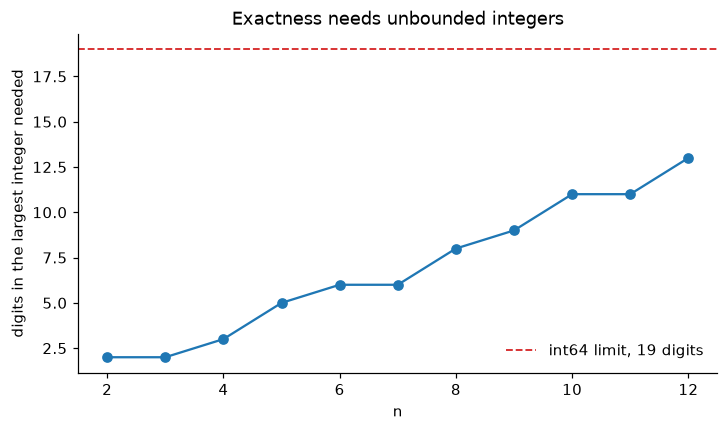

In [5]:
fig, ax = plt.subplots()
ax.plot(sizes, digits, marker="o")
ax.axhline(19, ls="--", c="#d62728", lw=1.2, label="int64 limit, 19 digits")
ax.set_xlabel("n"); ax.set_ylabel("digits in the largest integer needed")
ax.set_title("Exactness needs unbounded integers")
ax.legend(frameon=False); plt.show()